# 04 — Particle Filter (Monte Carlo) Localization

**Section:** Localization · **Mirrors MATLAB:** *Monte Carlo Localization*

The particle filter represents the belief over robot pose with a set of weighted samples (particles). At each step we (1) propagate each particle through the motion model, (2) weight by observation likelihood, (3) resample proportional to weights.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

T = 120
dt = 0.1

# Figure-8 ground-truth path
true_x = np.zeros((T, 3))
for t in range(T):
    a = t * dt
    true_x[t] = [5 * np.sin(a), 3 * np.sin(2 * a), a]

landmarks = np.array([[6, 0], [-6, 0], [0, 4], [0, -4], [4, 4], [-4, -4]])


In [2]:
N = 600
# Initial particles spread around the origin
particles = np.zeros((N, 3))
particles[:, :2] = np.random.uniform(-2, 2, (N, 2))
particles[:, 2] = np.random.uniform(-np.pi, np.pi, N)

est_hist, particle_hist = [], []
range_noise = 0.25

for t in range(T):
    u = (true_x[t] - true_x[t - 1]) if t > 0 else np.zeros(3)
    particles += u + np.random.randn(N, 3) * np.array([0.08, 0.08, 0.04])

    # Range observations to each landmark
    z = np.linalg.norm(landmarks - true_x[t, :2], axis=1) + np.random.randn(len(landmarks)) * range_noise
    expected = np.linalg.norm(landmarks[:, None, :] - particles[None, :, :2], axis=2)  # (M, N)
    err = (z[:, None] - expected) / range_noise
    log_w = -0.5 * np.sum(err ** 2, axis=0)
    w = np.exp(log_w - log_w.max())
    w /= w.sum()

    # Systematic resample
    idx = np.searchsorted(np.cumsum(w), (np.arange(N) + np.random.random()) / N)
    particles = particles[idx]

    est_hist.append(particles.mean(axis=0))
    if t in (0, T // 3, 2 * T // 3, T - 1):
        particle_hist.append((t, particles.copy()))

est_hist = np.array(est_hist)
err = np.linalg.norm(est_hist[:, :2] - true_x[:, :2], axis=1)
print(f"Mean position error: {err.mean():.3f} m")


Mean position error: 0.092 m


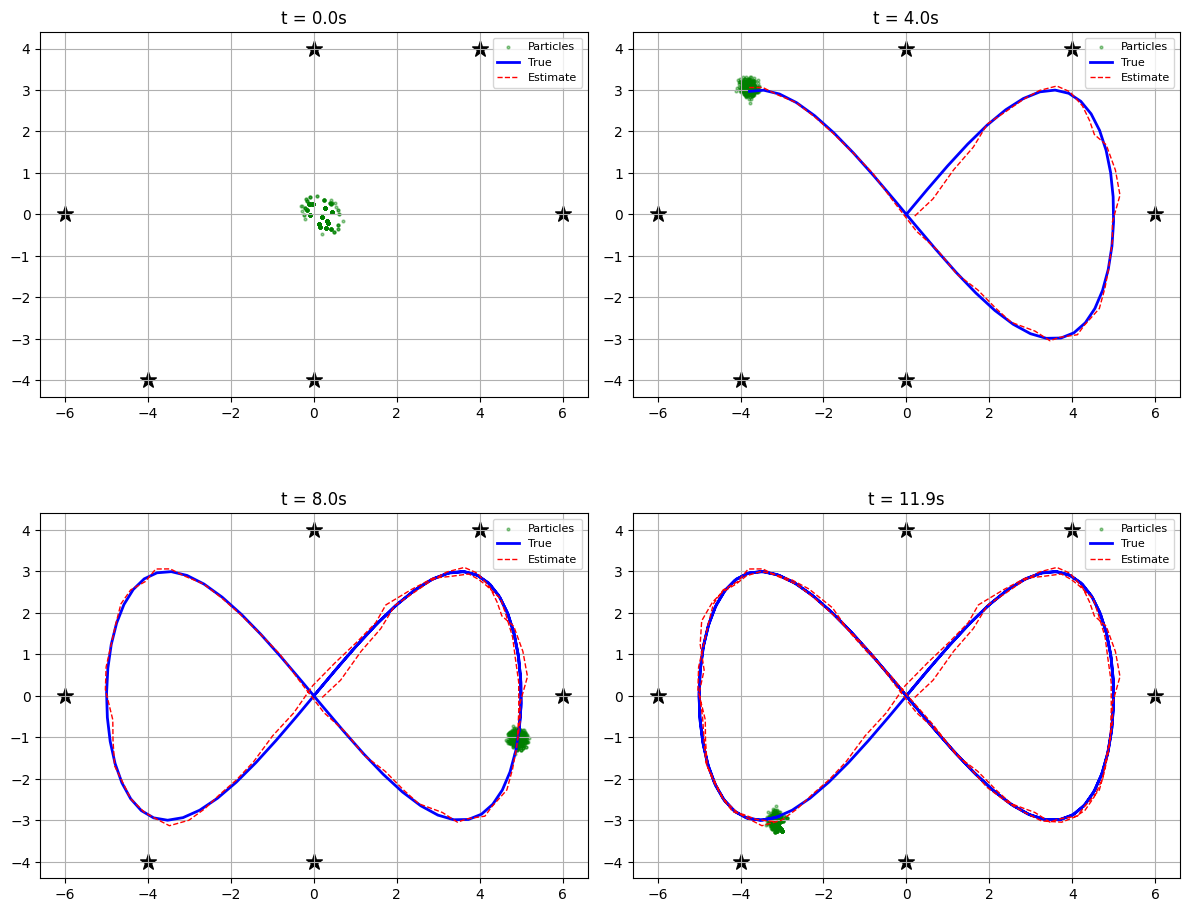

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for ax, (t, p) in zip(axs.flat, particle_hist):
    ax.scatter(p[:, 0], p[:, 1], c='g', s=4, alpha=0.4, label='Particles')
    ax.plot(true_x[:t + 1, 0], true_x[:t + 1, 1], 'b-', lw=2, label='True')
    ax.plot(est_hist[:t + 1, 0], est_hist[:t + 1, 1], 'r--', lw=1, label='Estimate')
    ax.scatter(landmarks[:, 0], landmarks[:, 1], c='k', marker='*', s=140)
    ax.set_title(f't = {t * dt:.1f}s')
    ax.set_aspect('equal'); ax.grid(); ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
